In [1]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [ ]:
def generate_worker_day(shift_hours=8, start_hour=8, day_wise_bias=1):
    """
    Generate a 1D sequence of worker states (working/idle) for a full shift.
    
    Parameters:
    - shift_hours: total shift duration in hours (default 8)
    - start_hour: starting hour of shift (default 8, meaning 8:00 AM)
    - day_wise_bias: multiplier to adjust overall efficiency for the day (default 1)
    
    Returns:
    - numpy array of 0s (idle) and 1s (working) for each frame
    """
    # total_frames = shift_hours * 3600 * fps
    total_frames = shift_hours * 1800  # Using 1800 per hour as our detection model predict every 2 seconds
    sequence = []
    
    # Define time blocks with their target efficiencies
    # Each block: (start_hour, end_hour, target_efficiency)
    time_blocks = [
        (8.0, 9.0, 0.60),    # 08:00-09:00: Ramp-up/Warm-up (60%)
        (9.0, 11.0, 0.85),   # 09:00-11:00: Peak Performance (85%)
        (11.0, 12.0, 0.75),  # 11:00-12:00: Pre-Lunch Fatigue (75%)
        (12.0, 13.0, 0.00),  # 12:00-13:00: Lunch Break (0%)
        (13.0, 14.0, 0.70),  # 13:00-14:00: Post-Lunch Slump (70%)
        (14.0, 15.5, 0.80),  # 14:00-15:30: Second Wind (80%)
        (15.5, 16.0, 0.65)   # 15:30-16:00: End-of-Shift Wind-down (65%)
    ]
    
    # Smooth transition parameters
    TRANSITION_PROB_CONTINUE = 0.98  # Probability to continue working if already working
    TRANSITION_PROB_BASE_START = 0.03  # Base probability to start working when idle
    
    for frame_idx in range(total_frames):
        # Calculate current hour of day (with fractional hours)
        current_hour = start_hour + (frame_idx / (1800))
        
        # 1. Determine ground truth efficiency target for this frame
        E_target = 0.85  # default fallback
        for start, end, efficiency in time_blocks:
            if start <= current_hour < end:
                E_target = efficiency
                break
        
        # Apply day-wise bias
        E_target *= day_wise_bias
        
        # 2. Simulate bursty micro-behavior with momentum
        if len(sequence) == 0:
            # First frame: initialize based on target efficiency
            state = 1 if np.random.rand() < E_target else 0
        else:
            prev_state = sequence[-1]
            
            if prev_state == 1:
                # Working: likely to continue working (momentum)
                # Higher efficiency periods have slightly higher continuation probability
                prob_continue = TRANSITION_PROB_CONTINUE + (E_target * 0.01)
                prob_continue = min(prob_continue, 0.995)  # Cap at 99.5%
                state = 1 if np.random.rand() < prob_continue else 0
            else:
                # Idle: probability to start working depends on target efficiency
                # Higher target efficiency = faster restart
                prob_start = TRANSITION_PROB_BASE_START * (E_target / 0.85)
                state = 1 if np.random.rand() < prob_start else 0
        
        sequence.append(state)
    
    return np.array(sequence)

In [ ]:
full_data_raw = []
days = 17
window_per_day = 6*8
for d in range(days):
    # Add a day-of-week effect: Sun=0.9, Wed=1.0, Thu=0.95, etc.
    dow = d % 5
    multiplier = 1.0
    if dow == 0: multiplier = 0.9   # Sunday
    elif dow == 4: multiplier = 0.95 # Thursday
    full_data_raw.append(generate_worker_day(day_wise_bias=multiplier))

In [ ]:
full_data_raw[0], full_data_raw[0].shape

(array([0, 0, 0, ..., 0, 0, 0]), (14400,))

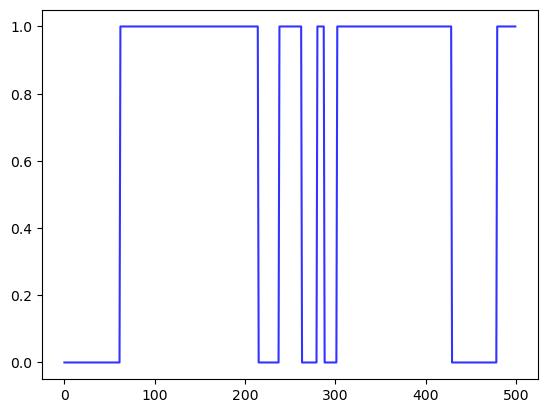

In [ ]:
plt.plot(full_data_raw[0][:500], 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)

In [ ]:
full_data_array = np.array(full_data_raw)
print(full_data_array.shape)
full_data = full_data_array.reshape(days, -1)
print(full_data.shape)

(17, 14400)
(17, 14400)


In [ ]:
def window_wise_feature_calculation(window_data):
    eff = np.mean(window_data)
    transitions = np.sum(np.abs(np.diff(window_data)))
    # print(f"Transitions in window: {transitions}")
    vol = transitions / (len(window_data) / 30)  # transitions per minute
    # print(f"Window Efficiency: {eff:.3f}, Transition Volatility: {vol:.2f} transitions/min")
    return eff, vol

In [ ]:
full_data_with_feature = []
for i in range(days):
    one_day_data = full_data[i]
    one_day_data_windowed = one_day_data.reshape(window_per_day,-1)
    day_data_with_feature = []
    for j in range(window_per_day):
        window_data = one_day_data_windowed[j]
        feature_value = window_wise_feature_calculation(window_data)
        day_data_with_feature.append(feature_value)
    full_data_with_feature.append(day_data_with_feature)

In [ ]:
full_data_with_feature_array = np.array(full_data_with_feature)
print(full_data_with_feature_array.shape)

(17, 48, 2)


In [ ]:

test_data = full_data_with_feature_array[15:17]  # Use the last 2 days for testing
train_data = full_data_with_feature_array[:15]  # Use the first 15 days for training


In [ ]:
from tensorly.decomposition import parafac

# Perform CP decomposition (rank R=2)
R = 2
weights, factors = parafac(train_data, rank=R, normalize_factors=True)

# factors[0] = Day factor (u_r) shape (days, R)
# factors[1] = Block factor (v_r) shape (blocks, R)
# factors[2] = Feature factor (w_r) shape (features, R)

day_factors = factors[0]   # (10, 2)
block_factors = factors[1] # (48, 2)
feature_factors = factors[2] # (2, 2)
print(day_factors.shape, block_factors.shape, feature_factors.shape)

(15, 2) (48, 2) (2, 2)


### AR

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

N_fd = 2  # forecast next 2 days
forecast_day_factors = np.zeros((N_fd, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=N_fd)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((N_fd, window_per_day, 2))
for i in range(N_fd):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * block_factors[:, r], feature_factors[:, r])

In [ ]:
efficiency_flatted_train_data = train_data[:,:,0].reshape(-1)
print(f"Train Efficiency shape: {efficiency_flatted_train_data.shape}")
efficiency_flatted_test_data = test_data[:,:,0].reshape(-1)
print(f"Test Efficiency shape: {efficiency_flatted_test_data.shape}")
efficiency_flatted_forecast = forecast_tensor[:,:,0].reshape(-1)
print(f"Forecast Efficiency shape: {efficiency_flatted_forecast.shape}")

Train Efficiency shape: (720,)
Test Efficiency shape: (96,)
Forecast Efficiency shape: (96,)


In [ ]:
efficiency_flatted_test_data[:10], efficiency_flatted_forecast[:10]

(array([0.59      , 0.43      , 0.68666667, 0.22666667, 0.56      ,
        0.81333333, 0.65666667, 0.49333333, 0.48666667, 0.68666667]),
 array([0.61352093, 0.63377173, 0.61473665, 0.58608645, 0.59690754,
        0.58683133, 0.61336588, 0.71476899, 0.66128144, 0.71204257]))

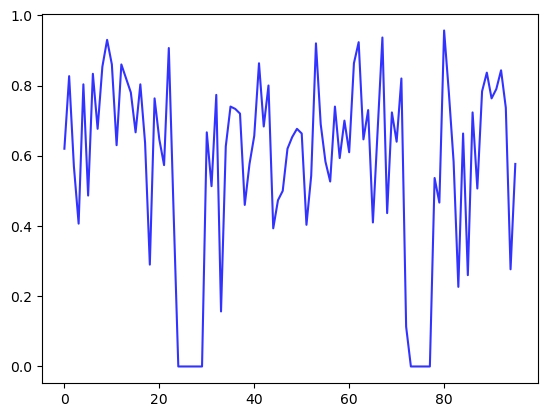

In [ ]:
plt.plot(efficiency_flatted_train_data[:96], 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)

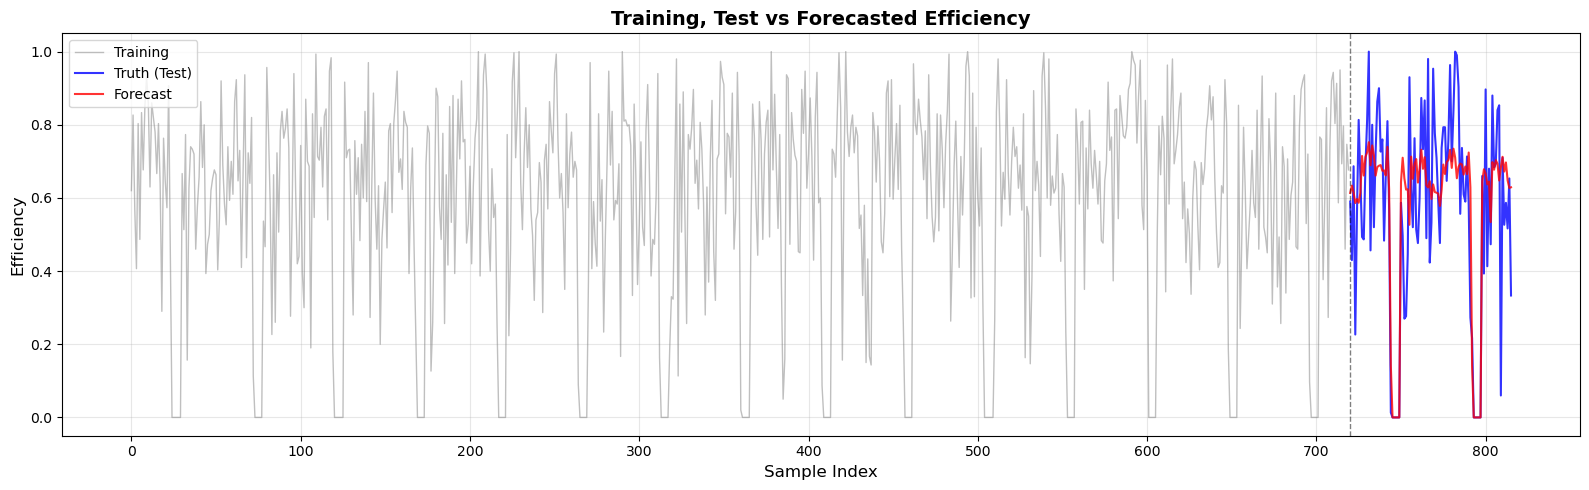

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 5))

# Plot training data (background)
train_len = len(efficiency_flatted_train_data)
plt.plot(np.arange(train_len), efficiency_flatted_train_data, 'gray', linewidth=1, label='Training', alpha=0.5)

# Plot test vs forecast overlapping (your original style)
start_idx = train_len
test_len = len(efficiency_flatted_test_data)
x_test = np.arange(start_idx, start_idx + test_len)

plt.plot(x_test, efficiency_flatted_test_data, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(x_test, efficiency_flatted_forecast[:test_len], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Add separator line
plt.axvline(x=train_len, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.title('Training, Test vs Forecasted Efficiency', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

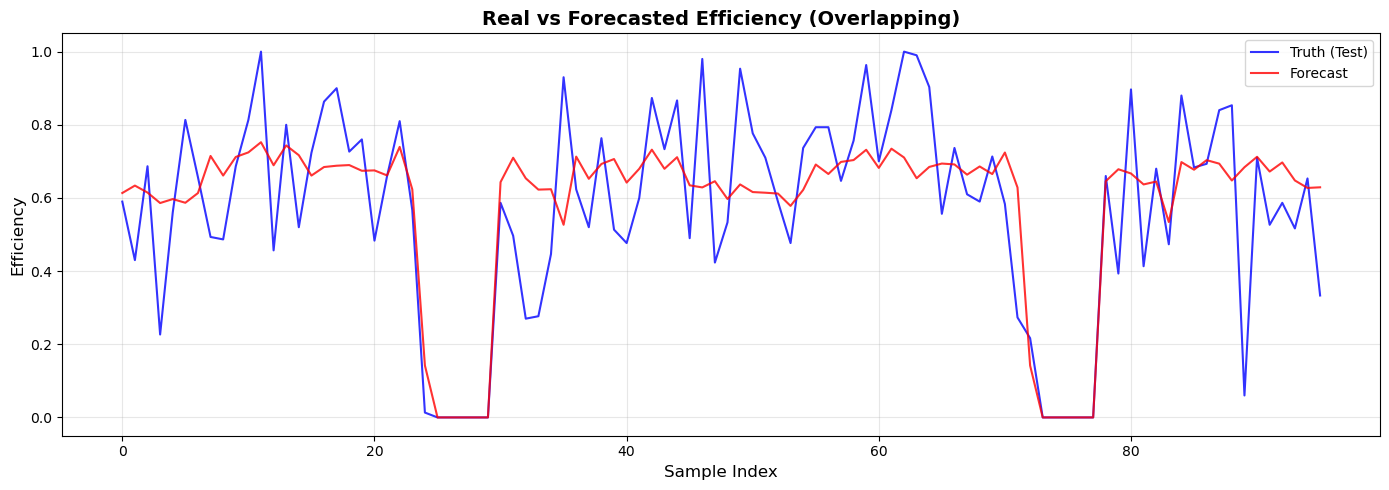

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(efficiency_flatted_test_data, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(efficiency_flatted_forecast[:len(efficiency_flatted_test_data)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.title('Real vs Forecasted Efficiency (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Calculate errors
errors = efficiency_flatted_test_data - efficiency_flatted_forecast[:len(efficiency_flatted_test_data)]
abs_errors = np.abs(errors)

# Method 1: Statistical thresholds
mean_error = np.mean(abs_errors)
std_error = np.std(abs_errors)

# Suggested thresholds
thresholds = {
    'moderate': mean_error + std_error,      # 1 standard deviation
    'high': mean_error + 2*std_error,        # 2 standard deviations  
    'extreme': mean_error + 3*std_error      # 3 standard deviations
}

print(f"Mean absolute error: {mean_error:.4f}")
print(f"Std of errors: {std_error:.4f}")
print(f"\nSuggested thresholds:")
print(f"  Moderate error: > {thresholds['moderate']:.4f}")
print(f"  High error: > {thresholds['high']:.4f}")
print(f"  Extreme error: > {thresholds['extreme']:.4f}")

# Method 2: Percentage threshold (e.g., 20% error relative to value range)
value_range = efficiency_flatted_test_data.max() - efficiency_flatted_test_data.min()
percentage_threshold = 0.20 * value_range  # 20% of range
print(f"\n20% of value range: {percentage_threshold:.4f}")

# Method 3: Fixed threshold based on business logic
fixed_threshold = 0.15  # If efficiency values are 0-1 scale, 15% error
print(f"Fixed threshold (0.15): {fixed_threshold:.4f}")

# Choose your threshold
THRESHOLD = thresholds['high']  # or percentage_threshold or fixed_threshold
print(f"\nUsing threshold: {THRESHOLD:.4f}")

Mean absolute error: 0.1324
Std of errors: 0.1165

Suggested thresholds:
  Moderate error: > 0.2489
  High error: > 0.3654
  Extreme error: > 0.4820

20% of value range: 0.2000
Fixed threshold (0.15): 0.1500

Using threshold: 0.3654


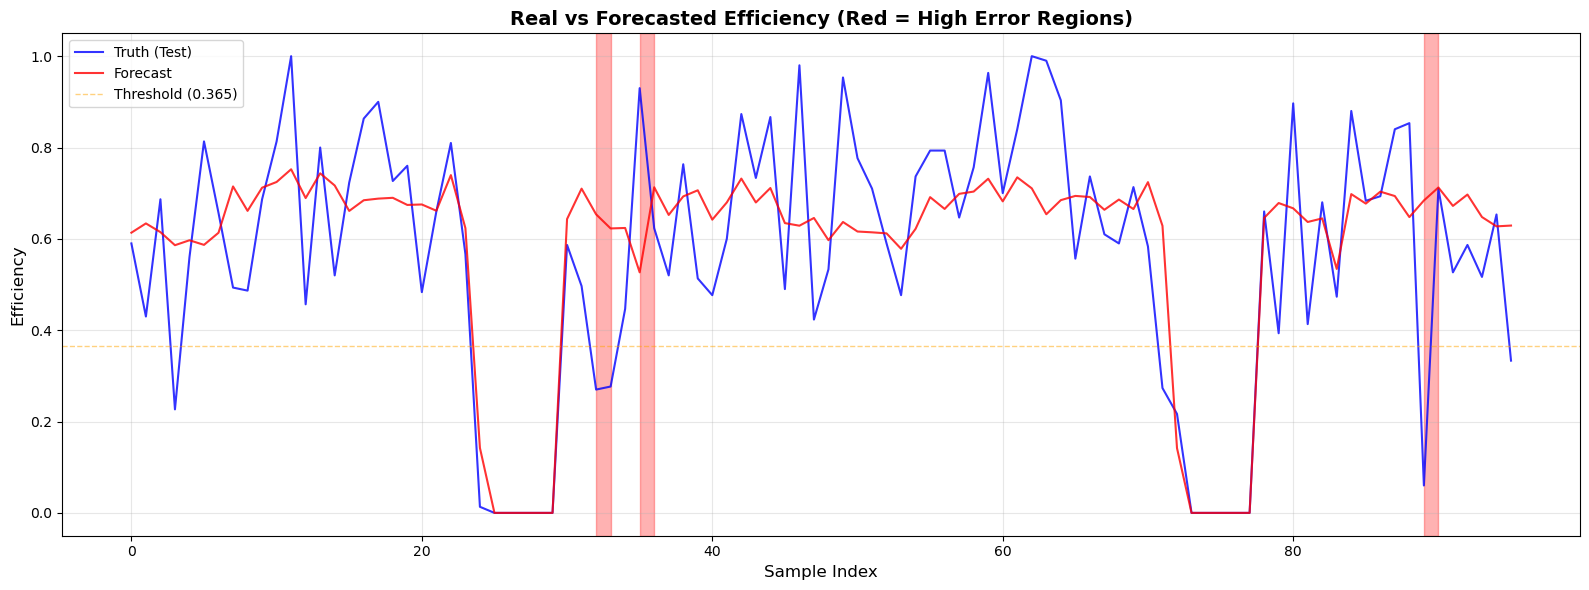

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Calculate where errors exceed threshold
test_values = efficiency_flatted_test_data
forecast_values = efficiency_flatted_forecast[:len(test_values)]
errors = np.abs(test_values - forecast_values)
error_exceeds = errors > THRESHOLD

# Create figure
fig, ax = plt.subplots(figsize=(16, 6))

# Plot background patches for error regions
if np.any(error_exceeds):
    # Find continuous regions where error exceeds threshold
    in_region = False
    start_idx = 0
    
    for i, exceeds in enumerate(error_exceeds):
        if exceeds and not in_region:
            # Start of error region
            start_idx = i
            in_region = True
        elif not exceeds and in_region:
            # End of error region
            ax.axvspan(start_idx, i, alpha=0.3, color='red', label='High Error Region' if start_idx == 0 else "")
            in_region = False
    
    # Handle case where error region goes to the end
    if in_region:
        ax.axvspan(start_idx, len(error_exceeds), alpha=0.3, color='red')

# Plot the data
ax.plot(test_values, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
ax.plot(forecast_values, 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Add threshold line
ax.axhline(y=THRESHOLD, color='orange', linestyle='--', linewidth=1, alpha=0.5, label=f'Threshold ({THRESHOLD:.3f})')

# Formatting
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Efficiency', fontsize=12)
ax.set_title('Real vs Forecasted Efficiency (Red = High Error Regions)', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# calculate MSE for efficiency
mse_efficiency = np.mean((efficiency_flatted_test_data - efficiency_flatted_forecast[:len(efficiency_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Efficiency Forecast: {mse_efficiency:.4f}")

Mean Squared Error for Efficiency Forecast: 0.0311


In [ ]:
volatility_flatted_train_data = train_data[:,:,1].reshape(-1)
print(f"Train Volatility shape: {volatility_flatted_train_data.shape}")
volatility_flatted_test_data = test_data[:,:,1].reshape(-1)
print(f"Test Volatility shape: {volatility_flatted_test_data.shape}")
volatility_flatted_forecast = forecast_tensor[:,:,1].reshape(-1)
print(f"Forecast Volatility shape: {volatility_flatted_forecast.shape}")

Train Volatility shape: (720,)
Test Volatility shape: (96,)
Forecast Volatility shape: (96,)


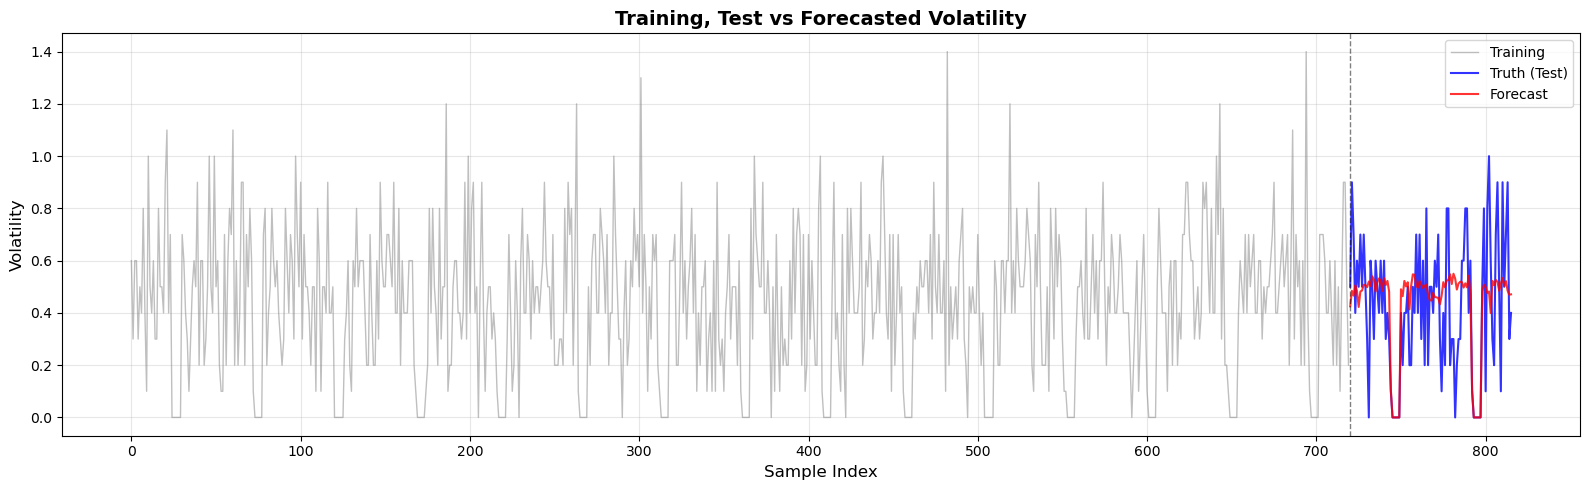

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 5))

# Plot training data (background)
train_len = len(volatility_flatted_train_data)
plt.plot(np.arange(train_len), volatility_flatted_train_data, 'gray', linewidth=1, label='Training', alpha=0.5)

# Plot test vs forecast overlapping (your original style)
start_idx = train_len
test_len = len(volatility_flatted_test_data)
x_test = np.arange(start_idx, start_idx + test_len)

plt.plot(x_test, volatility_flatted_test_data, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(x_test, volatility_flatted_forecast[:test_len], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Add separator line
plt.axvline(x=train_len, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.title('Training, Test vs Forecasted Volatility', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

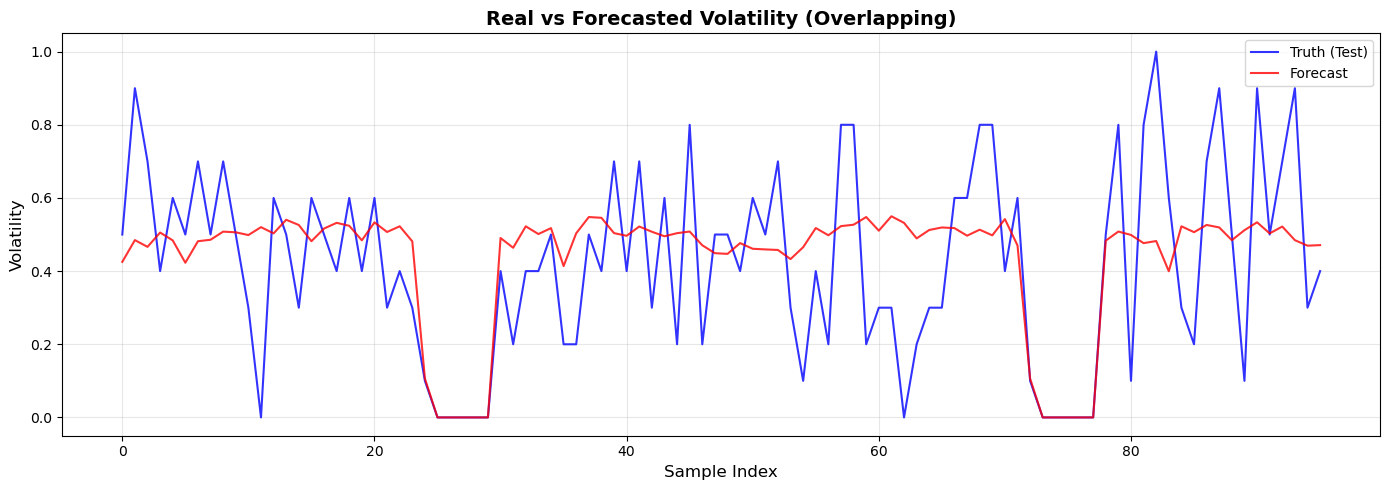

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(volatility_flatted_test_data, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(volatility_flatted_forecast[:len(volatility_flatted_test_data)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.title('Real vs Forecasted Volatility (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# calculate MSE for volatility
mse_volatility = np.mean((volatility_flatted_test_data - volatility_flatted_forecast[:len(volatility_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Volatility Forecast: {mse_volatility:.4f}")

Mean Squared Error for Volatility Forecast: 0.0462


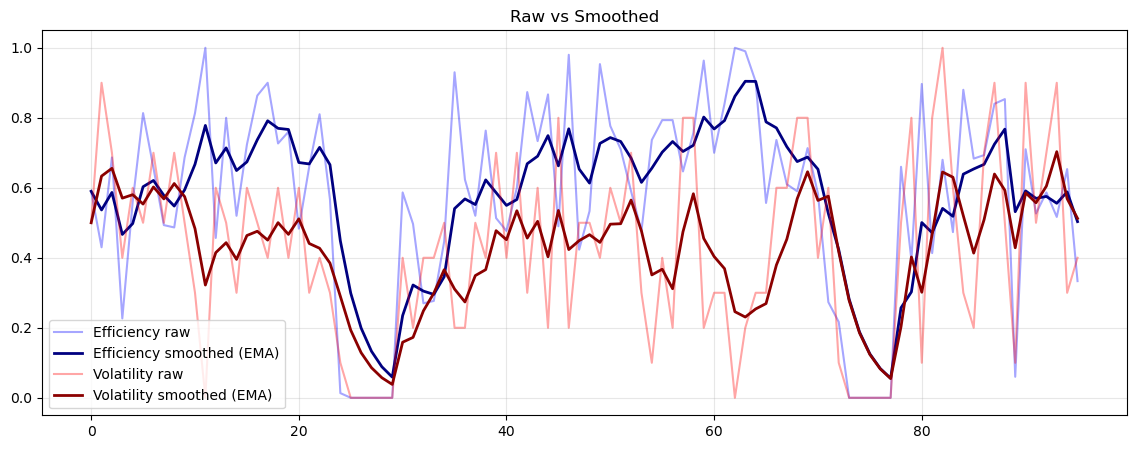

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Example input arrays (replace with yours)
eff = efficiency_flatted_test_data.copy()
vol = volatility_flatted_test_data.copy()

# 1) EMA smoothing (recommended)
eff_ema = pd.Series(eff).ewm(span=5, adjust=False).mean().to_numpy()
vol_ema = pd.Series(vol).ewm(span=5, adjust=False).mean().to_numpy()

# 2) Rolling mean (alternative)
eff_roll = pd.Series(eff).rolling(window=5, min_periods=1).mean().to_numpy()
vol_roll = pd.Series(vol).rolling(window=5, min_periods=1).mean().to_numpy()

# 3) Savitzky-Golay (alternative)
# window_length must be odd and <= len(series)
eff_sg = savgol_filter(eff, window_length=9, polyorder=2, mode="interp")
vol_sg = savgol_filter(vol, window_length=9, polyorder=2, mode="interp")

# Keep valid ranges
eff_ema = np.clip(eff_ema, 0, 1)
vol_ema = np.maximum(vol_ema, 0)

# Quick comparison plot (EMA)
plt.figure(figsize=(14, 5))
plt.plot(eff, alpha=0.35, label="Efficiency raw", color="blue")
plt.plot(eff_ema, linewidth=2, label="Efficiency smoothed (EMA)", color="navy")
plt.plot(vol, alpha=0.35, label="Volatility raw", color="red")
plt.plot(vol_ema, linewidth=2, label="Volatility smoothed (EMA)", color="darkred")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Raw vs Smoothed")
plt.show()

### SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

N_fd = 2
forecast_day_factors = np.zeros((N_fd, R))

for r in range(R):
    series = day_factors[:, r]
    # SARIMA with weekly seasonality
    model = SARIMAX(series, 
                    order=(1,0,1),      # (p,d,q)
                    seasonal_order=(1,0,1,5))  # (P,D,Q,S) S=5 for weekly
    model_fit = model.fit(disp=False)
    forecast = model_fit.forecast(steps=N_fd)
    forecast_day_factors[:, r] = forecast
    

# Reconstruct forecast tensor
forecast_tensor = np.zeros((N_fd, window_per_day, 2))
for i in range(N_fd):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * block_factors[:, r], feature_factors[:, r])

/home/kibria/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/kibria/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/kibria/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kibria/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimi

In [ ]:
efficiency_flatted_train_data_sar = train_data[:,:,0].reshape(-1)
efficiency_flatted_test_data_sar = test_data[:,:,0].reshape(-1)
efficiency_flatted_forecast_sar = forecast_tensor[:,:,0].reshape(-1)

volatility_flatted_train_data_sar = train_data[:,:,1].reshape(-1)
volatility_flatted_test_data_sar = test_data[:,:,1].reshape(-1)
volatility_flatted_forecast_sar = forecast_tensor[:,:,1].reshape(-1)


In [ ]:
import pandas as pd 
total_days = 17
windows_per_day = 48

efficiency_all = np.round(np.concatenate([efficiency_flatted_train_data, efficiency_flatted_test_data]), 2)
volatility_all = np.round(np.concatenate([volatility_flatted_train_data, volatility_flatted_test_data]), 2)

df = pd.DataFrame({
    'day': np.repeat(np.arange(1, total_days + 1), windows_per_day),
    'window': np.tile(np.arange(windows_per_day), total_days),
    'efficiency': efficiency_all,
    'volatility': volatility_all
})
df.to_csv('worker_efficiency_volatility.csv', index=False)
print(df.head(10))

   day  window  efficiency  volatility
0    1       0        0.62         0.6
1    1       1        0.83         0.3
2    1       2        0.57         0.6
3    1       3        0.41         0.6
4    1       4        0.80         0.3
5    1       5        0.49         0.5
6    1       6        0.83         0.4
7    1       7        0.68         0.8
8    1       8        0.85         0.4
9    1       9        0.93         0.1


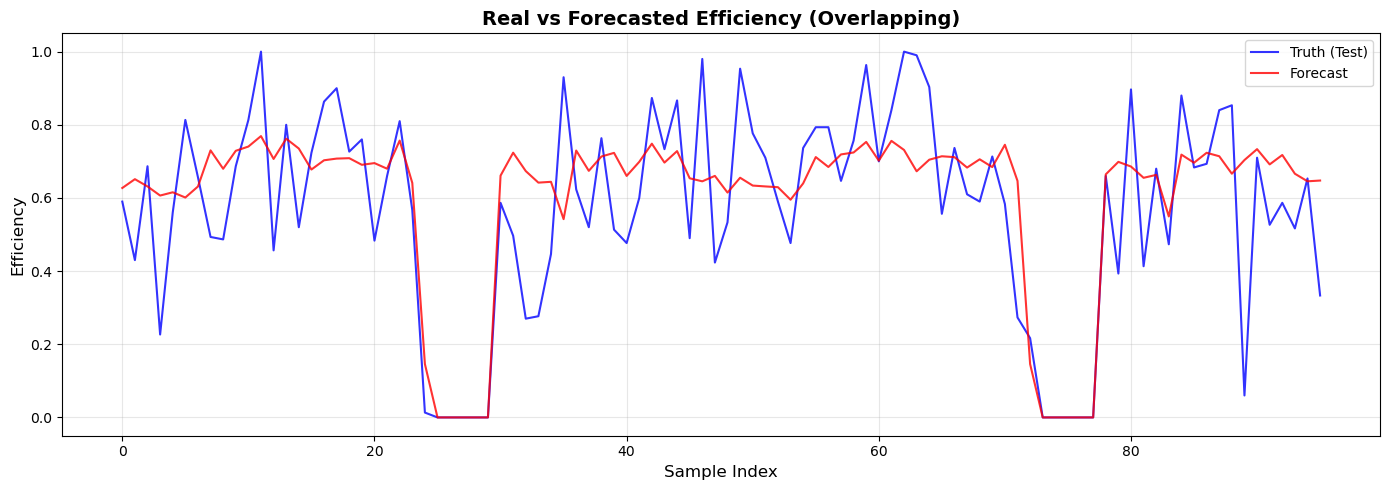

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(efficiency_flatted_test_data_sar, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(efficiency_flatted_forecast_sar[:len(efficiency_flatted_test_data_sar)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.title('Real vs Forecasted Efficiency (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

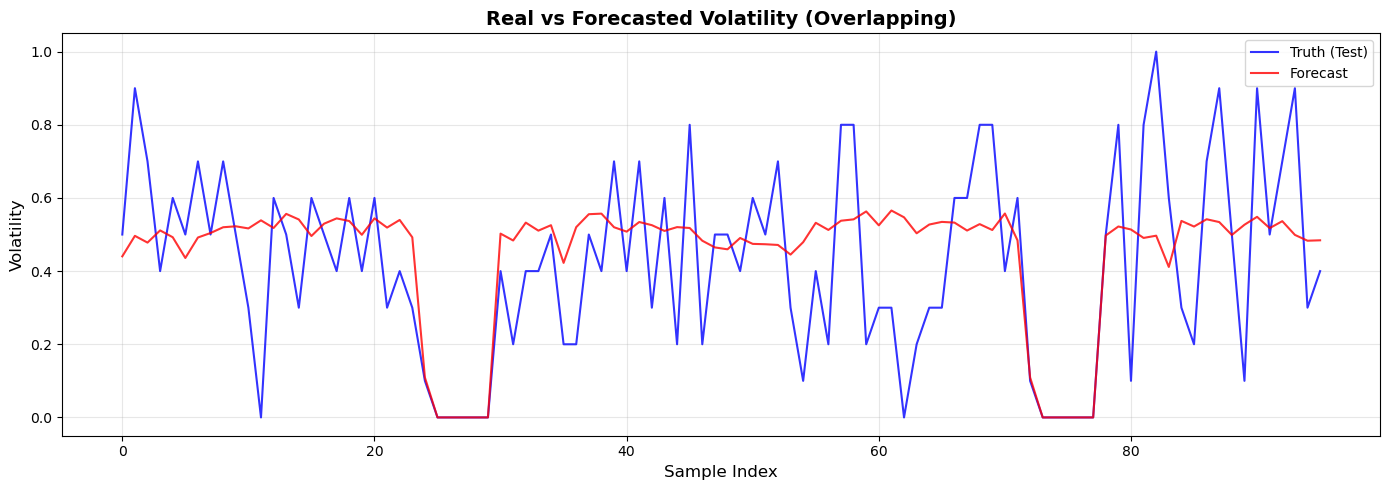

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(volatility_flatted_test_data_sar, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(volatility_flatted_forecast_sar[:len(volatility_flatted_test_data_sar)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.title('Real vs Forecasted Volatility (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# calculate MSE for efficiency
mse_efficiency = np.mean((efficiency_flatted_test_data - efficiency_flatted_forecast[:len(efficiency_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Efficiency Forecast: {mse_efficiency:.4f}")

mse_efficiency = np.mean((efficiency_flatted_test_data_sar - efficiency_flatted_forecast_sar[:len(efficiency_flatted_test_data_sar)]) ** 2)
print(f"Mean Squared Error for Efficiency Forecast: {mse_efficiency:.4f}")

# calculate MSE for volatility
mse_volatility = np.mean((volatility_flatted_test_data - volatility_flatted_forecast[:len(volatility_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Volatility Forecast: {mse_volatility:.4f}")

mse_volatility = np.mean((volatility_flatted_test_data_sar - volatility_flatted_forecast_sar[:len(volatility_flatted_test_data_sar)]) ** 2)
print(f"Mean Squared Error for Volatility Forecast: {mse_volatility:.4f}")


Mean Squared Error for Efficiency Forecast: 0.0311
Mean Squared Error for Efficiency Forecast: 0.0319
Mean Squared Error for Volatility Forecast: 0.0462
Mean Squared Error for Volatility Forecast: 0.0470


### Holt-winter

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

N_fd = 2
forecast_day_factors_halt = np.zeros((N_fd, R))

for r in range(R):
    series = day_factors[:, r]
    try:
        # Holt-Winters with weekly seasonality
        model = ExponentialSmoothing(series, 
                                     trend='add', 
                                     seasonal='add', 
                                     seasonal_periods=min(5, len(series)))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=N_fd)
        forecast_day_factors_halt[:, r] = forecast
    except:
        # Fallback to simple average if model fails
        forecast_day_factors_halt[:, r] = np.mean(series[-3:])

# Reconstruct forecast tensor (same as before)
forecast_tensor_halt = np.zeros((N_fd, window_per_day, 2))
for i in range(N_fd):
    for r in range(R):
        forecast_tensor_halt[i, :, :] += weights[r] * np.outer(
            forecast_day_factors_halt[i, r] * block_factors[:, r], 
            feature_factors[:, r]
        )

In [ ]:
efficiency_flatted_train_data_halt = train_data[:,:,0].reshape(-1)
efficiency_flatted_test_data_halt = test_data[:,:,0].reshape(-1)
efficiency_flatted_forecast_halt = forecast_tensor[:,:,0].reshape(-1)

volatility_flatted_train_data_halt = train_data[:,:,1].reshape(-1)
volatility_flatted_test_data_halt = test_data[:,:,1].reshape(-1)
volatility_flatted_forecast_halt = forecast_tensor[:,:,1].reshape(-1)


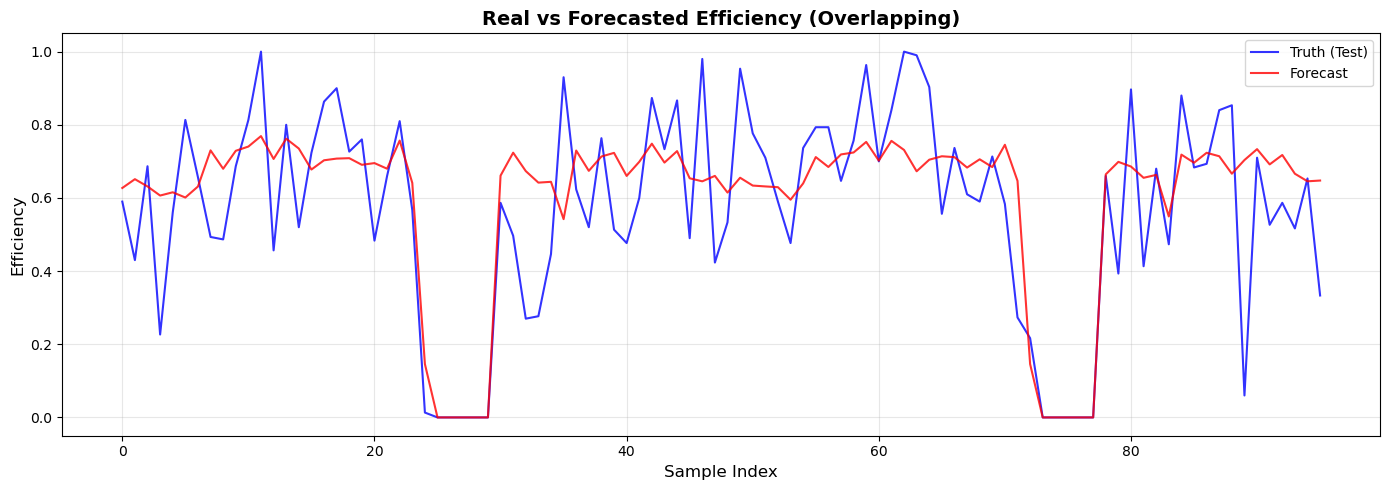

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(efficiency_flatted_test_data_halt, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(efficiency_flatted_forecast_halt[:len(efficiency_flatted_test_data_halt)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.title('Real vs Forecasted Efficiency (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

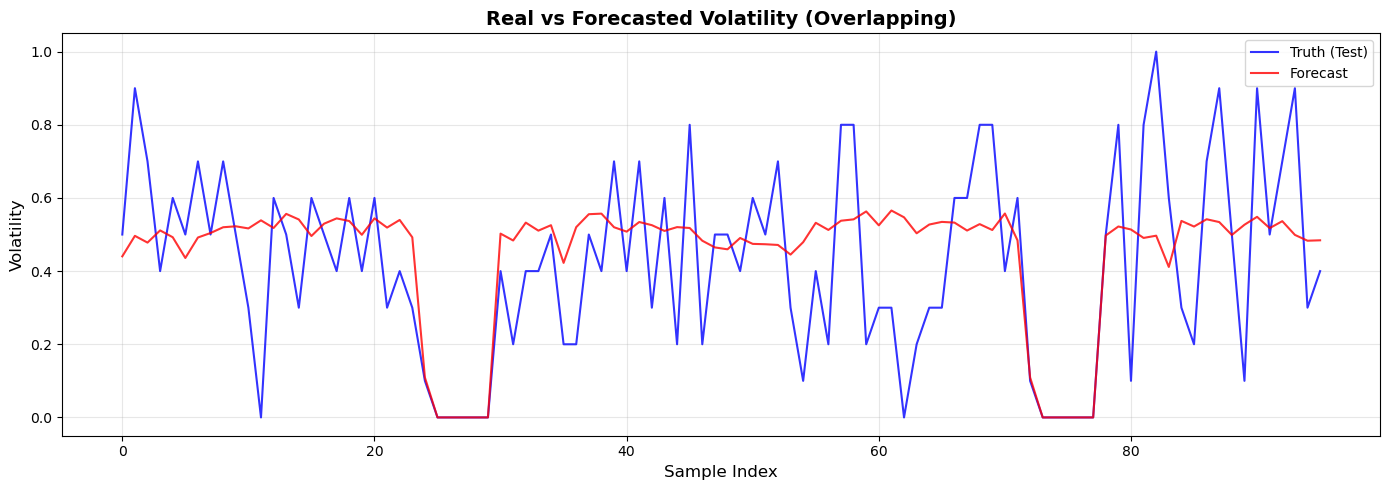

In [ ]:
import matplotlib.pyplot as plt

# Plot overlapping forecast vs test
plt.figure(figsize=(14, 5))

# Plot both on same axes
plt.plot(volatility_flatted_test_data_halt, 'b-', linewidth=1.5, label='Truth (Test)', alpha=0.8)
plt.plot(volatility_flatted_forecast_halt[:len(volatility_flatted_test_data_halt)], 'r-', linewidth=1.5, label='Forecast', alpha=0.8)

# Formatting
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.title('Real vs Forecasted Volatility (Overlapping)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# calculate MSE for efficiency
mse_efficiency = np.mean((efficiency_flatted_test_data - efficiency_flatted_forecast[:len(efficiency_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Efficiency Forecast: {mse_efficiency:.4f}")

mse_efficiency_sar = np.mean((efficiency_flatted_test_data_sar - efficiency_flatted_forecast_sar[:len(efficiency_flatted_test_data_sar)]) ** 2)
print(f"Mean Squared Error for Efficiency Forecast: {mse_efficiency_sar:.4f}")

mse_efficiency_halt_winter = np.mean((efficiency_flatted_test_data_halt - efficiency_flatted_forecast_halt[:len(efficiency_flatted_test_data_halt)]) ** 2)
print(f"Mean Squared Error for Halt Winter Forecast: {mse_efficiency_halt_winter:.4f}")

# calculate MSE for volatility
mse_volatility = np.mean((volatility_flatted_test_data - volatility_flatted_forecast[:len(volatility_flatted_test_data)]) ** 2)
print(f"Mean Squared Error for Volatility Forecast: {mse_volatility:.4f}")

mse_volatility_sar = np.mean((volatility_flatted_test_data_sar - volatility_flatted_forecast_sar[:len(volatility_flatted_test_data_sar)]) ** 2)
print(f"Mean Squared Error for Volatility Forecast: {mse_volatility_sar:.4f}")

mse_halt_winter_halt = np.mean((volatility_flatted_test_data_halt - volatility_flatted_forecast_halt[:len(volatility_flatted_test_data_halt)]) ** 2)
print(f"Mean Squared Error for Halt Winter Forecast: {mse_halt_winter_halt:.4f}")

Mean Squared Error for Efficiency Forecast: 0.0311
Mean Squared Error for Efficiency Forecast: 0.0319
Mean Squared Error for Halt Winter Forecast: 0.0319
Mean Squared Error for Volatility Forecast: 0.0462
Mean Squared Error for Volatility Forecast: 0.0470
Mean Squared Error for Halt Winter Forecast: 0.0470


### Direct forecast

In [ ]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Your flattened data
efficiency_flatted_train_data = train_data[:,:,0].reshape(-1)  # (480,)
efficiency_flatted_test_data = test_data[:,:,0].reshape(-1)    # (96,)
efficiency_flatted_forecast = forecast_tensor[:,:,0].reshape(-1)  # (96,)

print(f"Train shape: {efficiency_flatted_train_data.shape}")
print(f"Test shape: {efficiency_flatted_test_data.shape}")
print(f"Forecast shape: {efficiency_flatted_forecast.shape}")

# ============================================
# METHOD 1: Reshape back to (days, windows) for forecasting
# ============================================
# Reshape to (days, windows) - PRESERVE STRUCTURE
days_train = 10
windows = 48
train_reshaped = efficiency_flatted_train_data.reshape(days_train, windows)  # (10, 48)
test_reshaped = efficiency_flatted_test_data.reshape(2, windows)  # (2, 48)

# Forecast using window-wise approach
N_fd = 2
forecast_direct = np.zeros((N_fd, windows))

for w in range(windows):
    series = train_reshaped[:, w]  # (10,)
    try:
        model = ExponentialSmoothing(series, trend='add')
        fit = model.fit()
        forecast_direct[:, w] = fit.forecast(steps=N_fd)
    except:
        forecast_direct[:, w] = np.mean(series[-3:])

# Flatten for comparison
forecast_direct_flat = forecast_direct.reshape(-1)

# ============================================
# METHOD 2: Use flattened data with window position feature
# ============================================
# Create features: previous value + window position
X_train = []
y_train = []

for i in range(1, len(efficiency_flatted_train_data)):
    window_pos = i % windows
    X_train.append([efficiency_flatted_train_data[i-1], window_pos])
    y_train.append(efficiency_flatted_train_data[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Train model (simple linear regression)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Forecast next N_fd * windows steps
forecast_flattened = []
last_value = efficiency_flatted_train_data[-1]
last_pos = len(efficiency_flatted_train_data) % windows

for _ in range(N_fd * windows):
    next_pos = (last_pos + 1) % windows
    pred = model.predict([[last_value, last_pos]])[0]
    forecast_flattened.append(pred)
    last_value = pred
    last_pos = next_pos

forecast_flattened = np.array(forecast_flattened)

# ============================================
# METHOD 3: Simple baseline (last day repetition)
# ============================================
last_day = efficiency_flatted_train_data[-windows:]  # Last 48 values
forecast_baseline = np.tile(last_day, N_fd)  # Repeat for 2 days

# ============================================
# COMPARE ALL METHODS
# ============================================
print("\n" + "="*60)
print("FORECAST COMPARISON ON FLATTENED DATA")
print("="*60)

# Method 1: Window-wise (reshaped)
mse1 = mean_squared_error(efficiency_flatted_test_data, forecast_direct_flat)
mae1 = mean_absolute_error(efficiency_flatted_test_data, forecast_direct_flat)
r2_1 = r2_score(efficiency_flatted_test_data, forecast_direct_flat)

print("\nMethod 1 (Window-wise after reshape):")
print(f"  MSE: {mse1:.4f}")
print(f"  MAE: {mae1:.4f}")
print(f"  RMSE: {np.sqrt(mse1):.4f}")
print(f"  R²: {r2_1:.4f}")

# Method 2: Flattened with features
mse2 = mean_squared_error(efficiency_flatted_test_data, forecast_flattened)
mae2 = mean_absolute_error(efficiency_flatted_test_data, forecast_flattened)
r2_2 = r2_score(efficiency_flatted_test_data, forecast_flattened)

print("\nMethod 2 (Flattened with position features):")
print(f"  MSE: {mse2:.4f}")
print(f"  MAE: {mae2:.4f}")
print(f"  RMSE: {np.sqrt(mse2):.4f}")
print(f"  R²: {r2_2:.4f}")

# Method 3: Baseline
mse3 = mean_squared_error(efficiency_flatted_test_data, forecast_baseline)
mae3 = mean_absolute_error(efficiency_flatted_test_data, forecast_baseline)
r2_3 = r2_score(efficiency_flatted_test_data, forecast_baseline)

print("\nMethod 3 (Baseline - repeat last day):")
print(f"  MSE: {mse3:.4f}")
print(f"  MAE: {mae3:.4f}")
print(f"  RMSE: {np.sqrt(mse3):.4f}")
print(f"  R²: {r2_3:.4f}")

# ============================================
# PLOT COMPARISON
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Plot 1: Test vs Method 1
axes[0,0].plot(efficiency_flatted_test_data, 'b-', label='Test (Truth)', alpha=0.7)
axes[0,0].plot(forecast_direct_flat, 'r--', label='Method 1 (Window-wise)', alpha=0.7)
axes[0,0].set_title('Method 1: Window-wise Forecasting')
axes[0,0].set_xlabel('Sample Index')
axes[0,0].set_ylabel('Efficiency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Test vs Method 2
axes[0,1].plot(efficiency_flatted_test_data, 'b-', label='Test (Truth)', alpha=0.7)
axes[0,1].plot(forecast_flattened, 'g--', label='Method 2 (Flattened+Features)', alpha=0.7)
axes[0,1].set_title('Method 2: Flattened with Position Features')
axes[0,1].set_xlabel('Sample Index')
axes[0,1].set_ylabel('Efficiency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Test vs Method 3 (Baseline)
axes[1,0].plot(efficiency_flatted_test_data, 'b-', label='Test (Truth)', alpha=0.7)
axes[1,0].plot(forecast_baseline, 'm--', label='Method 3 (Baseline)', alpha=0.7)
axes[1,0].set_title('Method 3: Repeat Last Day')
axes[1,0].set_xlabel('Sample Index')
axes[1,0].set_ylabel('Efficiency')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: All methods together (first 96 samples)
axes[1,1].plot(efficiency_flatted_test_data, 'b-', label='Truth', linewidth=2)
axes[1,1].plot(forecast_direct_flat, 'r--', label='Method 1', alpha=0.7)
axes[1,1].plot(forecast_flattened, 'g--', label='Method 2', alpha=0.7)
axes[1,1].plot(forecast_baseline, 'm--', label='Method 3', alpha=0.7)
axes[1,1].set_title('All Methods Comparison')
axes[1,1].set_xlabel('Sample Index')
axes[1,1].set_ylabel('Efficiency')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PRINT SAMPLE PREDICTIONS
# ============================================
print("\n" + "="*60)
print("SAMPLE PREDICTIONS (First 10 samples of Day 11)")
print("="*60)
print(f"{'Sample':<10} {'Truth':<12} {'Method1':<12} {'Method2':<12} {'Method3':<12}")
print("-"*60)

for i in range(10):
    print(f"{i:<10} {efficiency_flatted_test_data[i]:<12.4f} "
          f"{forecast_direct_flat[i]:<12.4f} "
          f"{forecast_flattened[i]:<12.4f} "
          f"{forecast_baseline[i]:<12.4f}")

Train shape: (720,)
Test shape: (96,)
Forecast shape: (96,)


ValueError: cannot reshape array of size 720 into shape (10,48)

### For Synthetic data verifying purpose

In [ ]:
all_days_windowed = []
for i in range(days):
    daywise_data = full_data[i]
    daywise_data_windowed = daywise_data.reshape(8,-1).mean(axis=1)
    all_days_windowed.append(daywise_data_windowed)

In [ ]:
all_days_windowed

[array([0.61833333, 0.80388889, 0.72666667, 0.58944444, 0.        ,
        0.49611111, 0.70666667, 0.68666667]),
 array([0.78222222, 0.59166667, 0.815     , 0.62888889, 0.        ,
        0.74944444, 0.73111111, 0.64611111]),
 array([0.59388889, 0.77444444, 0.695     , 0.65666667, 0.02      ,
        0.57722222, 0.82222222, 0.63611111]),
 array([0.65722222, 0.53222222, 0.65833333, 0.69611111, 0.        ,
        0.53444444, 0.77222222, 0.75722222]),
 array([0.58222222, 0.66722222, 0.81611111, 0.60055556, 0.03277778,
        0.72388889, 0.72666667, 0.72333333]),
 array([0.62722222, 0.59444444, 0.66833333, 0.62833333, 0.03277778,
        0.565     , 0.84388889, 0.78277778]),
 array([0.51333333, 0.735     , 0.61722222, 0.59055556, 0.04444444,
        0.54444444, 0.71166667, 0.77722222]),
 array([0.75888889, 0.71166667, 0.68055556, 0.61666667, 0.        ,
        0.60611111, 0.69555556, 0.63944444]),
 array([0.54      , 0.68444444, 0.78555556, 0.65944444, 0.04777778,
        0.56277778, 

In [ ]:
all_days_windowed[0]

array([0.61833333, 0.80388889, 0.72666667, 0.58944444, 0.        ,
       0.49611111, 0.70666667, 0.68666667])

In [ ]:
all_days_windowed[1]

array([0.78222222, 0.59166667, 0.815     , 0.62888889, 0.        ,
       0.74944444, 0.73111111, 0.64611111])

In [ ]:
all_days_windowed[2]

array([0.59388889, 0.77444444, 0.695     , 0.65666667, 0.02      ,
       0.57722222, 0.82222222, 0.63611111])

In [ ]:
days = 5
fps = 25
shift_seconds = 8 * 3600
frames_per_day = shift_seconds * fps

In [ ]:
sunday_data = daywise_data[0]
sunday_data.shape

()

In [ ]:
windowed_sunday_data = sunday_data.reshape(window_per_day, window_size)
windowed_sunday_data.shape

(24, 30000)

In [ ]:
mean_efficiency_per_window = windowed_sunday_data.mean(axis=1)
mean_efficiency_per_window

array([0.5707    , 0.61816667, 0.61083333, 0.72123333, 0.72853333,
       0.74323333, 0.7041    , 0.70006667, 0.70776667, 0.6819    ,
       0.68466667, 0.6695    , 0.0029    , 0.        , 0.        ,
       0.6637    , 0.7033    , 0.6362    , 0.68033333, 0.71463333,
       0.66966667, 0.69523333, 0.69126667, 0.60873333])

Text(0.5, 0, '10-minute Window Index')

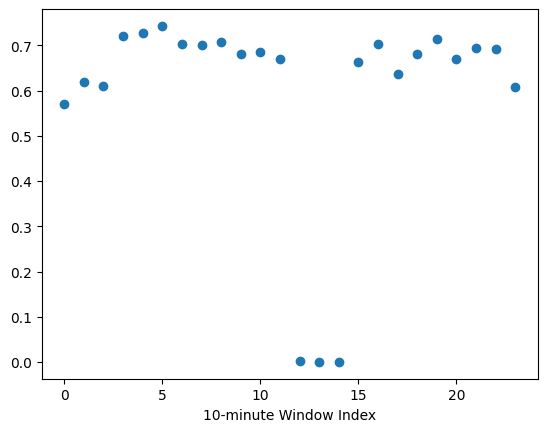

In [ ]:
plt.scatter(range(len(mean_efficiency_per_window)), mean_efficiency_per_window)
plt.xlabel('10-minute Window Index')

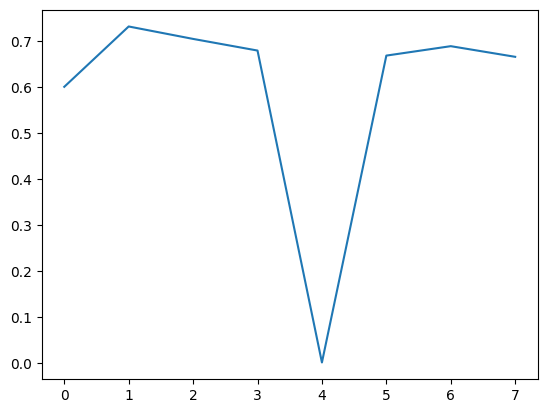

In [ ]:
hour_wise_mean = sunday_data.reshape(-1, 25*3600).mean(axis=1)
plt.plot(hour_wise_mean)

In [ ]:
hour_wise_mean

array([0.5999    , 0.731     , 0.70397778, 0.67868889, 0.00096667,
       0.66773333, 0.68821111, 0.66507778])